# Proyecto: Clásificador de Células Sanguíneas en Frotis de Sangre Periférica

## 1.0 Importación de las Librerías:


In [1]:
import os  # Para interactuar con funcionalidades del sistema operativo.
import os.path  # Para trabajar con rutas de archivos y comprobar la existencia de rutas y archivos.
import numpy as np  # Librería para cálculos numéricos eficientes.
import pandas as pd  # Para manipulación y análisis de datos.
import seaborn as sns  # Para visualización de datos estadísticos.
from pathlib import Path  # Para manipular rutas de archivos de manera más intuitiva.
import matplotlib.pyplot as plt  # Para generar gráficos y visualizaciones.
import matplotlib.image as mpimg  # Para leer y mostrar imágenes.

import tensorflow as tf  # Plataforma de machine learning.
import keras  # API de alto nivel para redes neuronales.

from keras import layers  # Componentes para construir capas en modelos de Keras.
from keras.models import Sequential  # Modelo de red neuronal secuencial en Keras.
from keras.preprocessing.image import ImageDataGenerator  # Para la generación de datos de imágenes para entrenamiento.
from keras.layers import Rescaling, Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # Capas específicas de redes convolucionales.
from keras import regularizers, optimizers  # Para regularización y optimización de modelos.
from keras.callbacks import EarlyStopping # Para detener el entrenamiento de un modelo cuando una métrica de desempeño deje de mejorar.
from keras import backend as K  # Para trabajar con el backend de TensorFlow.

import visualkeras  # Herramienta para visualizar arquitecturas de modelos de Keras.

from sklearn.metrics import classification_report  # Reporte de métricas para evaluación de clasificación.
from sklearn.metrics import confusion_matrix  # Matriz de confusión para evaluación de clasificación.

ModuleNotFoundError: No module named 'tensorflow.compat'

## 2.0 Carga de Datos

In [2]:
K.clear_session()  # Limpia la sesión de Keras.

In [ ]:
# Generando los paths de los directorios de trabajo.
total_dir = 'D:/Datasets/dataset_hematologia/Labelled_mix'

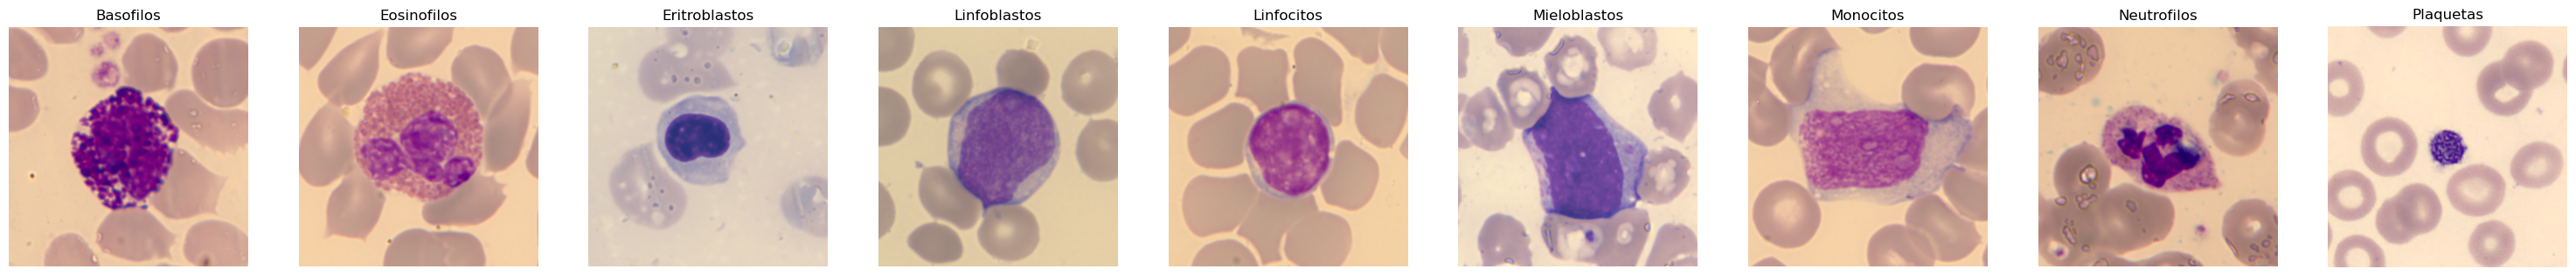

In [21]:
# Observar una imagen de cada clase de la carpeta total_dir.

fig, ax = plt.subplots(1, 9, figsize=(30, 15))
ax = ax.ravel()
plt.tight_layout()

for i, _dir in enumerate(os.listdir(total_dir)):
    ax[i].imshow(mpimg.imread(os.path.join(total_dir, _dir, os.listdir(os.path.join(total_dir, _dir))[0])))
    ax[i].set_title(_dir)
    ax[i].axis('off')

plt.show()

In [26]:
# Verificar en la carpeta principal cuantas imagenes hay en cada clase
print("Imágenes por clase:")
print("")
for _dir in os.listdir(total_dir):
    print(f'Hay {len(os.listdir(os.path.join(total_dir, _dir)))} imágenes de {_dir}')
print("")
print("Total de imágenes: ", sum([len(files) for r, d, files in os.walk(total_dir)]))

Imágenes por clase:

Hay 2241 imágenes de Basofilos
Hay 4134 imágenes de Eosinofilos
Hay 2061 imágenes de Eritroblastos
Hay 2557 imágenes de Linfoblastos
Hay 4260 imágenes de Linfocitos
Hay 2534 imágenes de Mieloblastos
Hay 3460 imágenes de Monocitos
Hay 6629 imágenes de Neutrofilos
Hay 2348 imágenes de Plaquetas

Total de imágenes:  30224


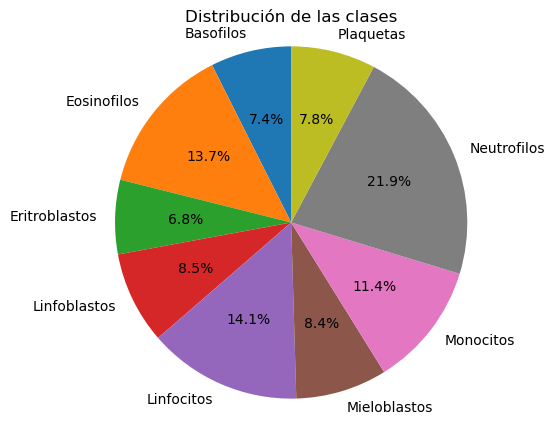

In [27]:
# Gráfico de pie para visualizar la distribución de las clases.
plt.figure(figsize=(5, 5))
plt.pie([len(os.listdir(os.path.join(total_dir, _dir))) for _dir in os.listdir(total_dir)],
        labels=[_dir for _dir in os.listdir(total_dir)],
        autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Distribución de las clases')
plt.show()

## 3.0 Preparando los datos

In [3]:
# Las clases se encuentran desbalanceadas, utilizaremos data augmentation para balancearlas y guardaremos las imágenes en la misma carpeta, hasta tener 7000 imágenes por clase.

# Generando los paths de los directorios de trabajo.
total_dir = 'D:/Datasets/dataset_hematologia/Labelled_mix'
train_dir = 'D:/Datasets/dataset_hematologia/Labelled_mix/train'
test_dir = 'D:/Datasets/dataset_hematologia/Labelled_mix/test'
val_dir = 'D:/Datasets/dataset_hematologia/Labelled_mix/val'

import os
import numpy as np
import matplotlib.image as mpimg


# Definiendo el generador de imágenes.
datagen = ImageDataGenerator(
    rotation_range=20,  # Rango de rotación de las imágenes.
    width_shift_range=0.2,  # Rango de traslación horizontal de las imágenes.
    height_shift_range=0.2,  # Rango de traslación vertical de las imágenes.
    shear_range=0.2,  # Rango de deformación de las imágenes.
    zoom_range=0.2,  # Rango de zoom de las imágenes.
    horizontal_flip=True,  # Volteo horizontal de las imágenes.
    vertical_flip=True,  # Volteo vertical de las imágenes.
    fill_mode='nearest',  # Relleno de los bordes de las imágenes.
)

# Contando el número de imágenes en cada clase.
print("Imágenes por clase:")
print("")
for _dir in os.listdir(total_dir):
    print(f'Hay {len(os.listdir(os.path.join(total_dir, _dir)))} imágenes de {_dir}')
print("")

# Generando imágenes de cada clase hasta tener 7000 imágenes por clase.
for _dir in os.listdir(total_dir):
    for i in range(7000 - len(os.listdir(os.path.join(total_dir, _dir)))):
        img = mpimg.imread(os.path.join(total_dir, _dir, os.listdir(os.path.join(total_dir, _dir))[i]))
        x = img.reshape((1,) + img.shape)
        j = 0
        for batch in datagen.flow(x, batch_size=1, save_to_dir=os.path.join(total_dir, _dir), save_prefix='img',
                                  save_format='.png'):
            j += 1
            if j >= 1:
                break

Imágenes por clase:

Hay 2241 imágenes de Basofilos
Hay 4134 imágenes de Eosinofilos
Hay 2061 imágenes de Eritroblastos
Hay 2557 imágenes de Linfoblastos
Hay 4260 imágenes de Linfocitos
Hay 2534 imágenes de Mieloblastos
Hay 3460 imágenes de Monocitos
Hay 6629 imágenes de Neutrofilos
Hay 2348 imágenes de Plaquetas



In [4]:
# Eliminamos de cada carpeta una cantidad de imágenes para que cada carpeta contenga 5900 imágenes, la eliminación se realiza de manera aleatoria.
import random
# Iterar sobre las subcarpetas/clases en total_dir
for _dir in os.listdir(total_dir):
    # Obtener la lista de imágenes en la subcarpeta actual
    images_list = os.listdir(os.path.join(total_dir, _dir))

    # Reorganizar aleatoriamente la lista de imágenes
    random.shuffle(images_list)

    # Determinar el número máximo de imágenes permitidas (5900)
    max_images = 5950
    if len(images_list) > max_images:
        # Eliminar imágenes adicionales aleatoriamente si hay más de 5900
        random.shuffle(images_list)
        for i in range(max_images, len(images_list)):
            os.remove(os.path.join(total_dir, _dir, images_list[i]))


In [8]:
import os
import random
from shutil import copyfile

# Definir las rutas de los directorios
total_dir = 'D:/Datasets/dataset_hematologia/Labelled_mix/'
train_dir = 'D:/Datasets/dataset_hematologia/Divided_Labelled_Mix/train'
test_dir = 'D:/Datasets/dataset_hematologia/Divided_Labelled_Mix/test'
val_dir = 'D:/Datasets/dataset_hematologia/Divided_Labelled_Mix/val'

# Crear directorios
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# Contar el número de imágenes en cada clase
class_counts = {}
for _dir in os.listdir(total_dir):
    class_counts[_dir] = len(os.listdir(os.path.join(total_dir, _dir)))
    print(f'Hay {class_counts[_dir]} imágenes de {_dir}')

# Distribuir las imágenes en los conjuntos de train, val y test
for _dir in os.listdir(total_dir):
    images = os.listdir(os.path.join(total_dir, _dir))
    random.shuffle(images)

    # Calcular las cantidades para train, val y test
    num_train = int(0.85 * class_counts[_dir])
    num_val = int(0.1 * class_counts[_dir])
    num_test = class_counts[_dir] - num_train - num_val

    # Crear directorios de destino antes de copiar
    os.makedirs(os.path.join(train_dir, _dir), exist_ok=True)
    os.makedirs(os.path.join(val_dir, _dir), exist_ok=True)
    os.makedirs(os.path.join(test_dir, _dir), exist_ok=True)

    # Copiar imágenes a los directorios correspondientes
    for i in range(num_train):
        src_path = os.path.join(total_dir, _dir, images[i])
        dst_path = os.path.join(train_dir, _dir, images[i])
        copyfile(src_path, dst_path)

    for i in range(num_train, num_train + num_val):
        src_path = os.path.join(total_dir, _dir, images[i])
        dst_path = os.path.join(val_dir, _dir, images[i])
        copyfile(src_path, dst_path)

    for i in range(num_train + num_val, num_train + num_val + num_test):
        src_path = os.path.join(total_dir, _dir, images[i])
        dst_path = os.path.join(test_dir, _dir, images[i])
        copyfile(src_path, dst_path)


Hay 5950 imágenes de Basofilos
Hay 5950 imágenes de Eosinofilos
Hay 5950 imágenes de Eritroblastos
Hay 5950 imágenes de Linfoblastos
Hay 5950 imágenes de Linfocitos
Hay 5950 imágenes de Mieloblastos
Hay 5950 imágenes de Monocitos
Hay 5950 imágenes de Neutrofilos
Hay 5950 imágenes de Plaquetas


In [14]:
# Generando los generadores de datos de imágenes para cada conjunto.

image_size = (150, 150)
batch_size = 64

train_datagen = ImageDataGenerator(
    rescale=1. / 255,  # Reescalar los valores de los pixeles de las imágenes.
    rotation_range=20,  # Rango de rotación de las imágenes.
    width_shift_range=0.2,  # Rango de traslación horizontal de las imágenes.
    height_shift_range=0.2,  # Rango de traslación vertical de las imágenes.
    shear_range=0.2,  # Rango de deformación de las imágenes.
    zoom_range=0.2,  # Rango de zoom de las imágenes.
    horizontal_flip=True,  # Volteo horizontal de las imágenes.
    vertical_flip=True,  # Volteo vertical de las imágenes.
    fill_mode='nearest',  # Relleno de los bordes de las imágenes.
)

val_datagen = ImageDataGenerator(
    rescale=1. / 255,  # Reescalar los valores de los pixeles de las imágenes.
)

test_datagen = ImageDataGenerator(
    rescale=1. / 255,  # Reescalar los valores de los pixeles de las imágenes.
)

In [15]:
# Aplicando los generadores de datos de imágenes a los conjuntos de datos.

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

test_ds = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

Found 45513 images belonging to 9 classes.
Found 5355 images belonging to 9 classes.
Found 2682 images belonging to 9 classes.


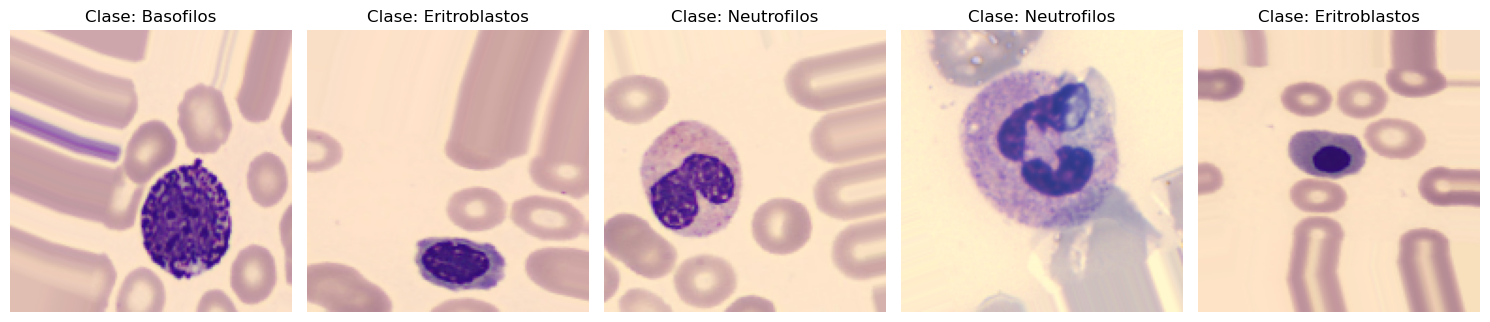

In [16]:
# Obtener la información de las clases y sus índices del generador de datos
class_indices = train_ds.class_indices

# Obtener los nombres de las clases a partir de los índices
class_names = list(class_indices.keys())

# Crear el subplot
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

# Iterar sobre los tamaños y mostrar las imágenes en subplots con los nombres de las clases
for i in range(5):
    img, label = train_ds.next()
    class_index = np.argmax(label[0])
    class_name = class_names[class_index]
    axes[i].imshow(img[0])
    axes[i].set_title(f'Clase: {class_name}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Entrenamiento de Modelos

In [17]:
K.clear_session()  # Limpia la sesión de Keras.

In [18]:

model_1 = Sequential([
    tf.keras.layers.Conv2D(16, (3,3), input_shape = (150, 150, 3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(16, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPool2D((2,2)),

    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

     tf.keras.layers.MaxPool2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPool2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation = "relu", padding="same"),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPool2D((2,2)),
   
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512, activation = "relu", kernel_regularizer=regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1024, activation = "relu", kernel_regularizer=regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(512, activation = "relu", kernel_regularizer=regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(9, activation = "softmax")
]) 



In [19]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Crear callbacks
model_checkpoint = ModelCheckpoint('mejor_modelo.h5', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=6, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

# Compilar el modelo
model_1.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(0.0004), metrics=['accuracy', 'Precision', 'Recall', 'AUC'])

In [20]:
# Entrenar el modelo con los callbacks
history = model_1.fit(train_ds, epochs=100, validation_data=val_ds, callbacks=[model_checkpoint, reduce_lr, early_stopping])

Epoch 1/100
712/712 [==============================] - 3284s 5s/step - loss: 1.6056 - accuracy: 0.4811 - precision: 0.6668 - recall: 0.3180 - auc: 0.8760 - val_loss: 2.7319 - val_accuracy: 0.3425 - val_precision: 0.3706 - val_recall: 0.3210 - val_auc: 0.7878 - lr: 4.0000e-04
Epoch 2/100
712/712 [==============================] - 3382s 5s/step - loss: 0.8807 - accuracy: 0.7728 - precision: 0.8215 - recall: 0.7127 - auc: 0.9691 - val_loss: 1.9456 - val_accuracy: 0.5935 - val_precision: 0.6178 - val_recall: 0.5632 - val_auc: 0.8871 - lr: 4.0000e-04
Epoch 3/100
712/712 [==============================] - 3241s 5s/step - loss: 0.6888 - accuracy: 0.8404 - precision: 0.8754 - recall: 0.8010 - auc: 0.9816 - val_loss: 1.0834 - val_accuracy: 0.7434 - val_precision: 0.7800 - val_recall: 0.7066 - val_auc: 0.9510 - lr: 4.0000e-04
Epoch 4/100
712/712 [==============================] - 3176s 4s/step - loss: 0.5782 - accuracy: 0.8735 - precision: 0.9005 - recall: 0.8461 - auc: 0.9870 - val_loss: 1.3279

In [121]:
# Obtener el promedio de las métricas de evaluación del modelo en train y val
train_acc = np.mean(history.history['accuracy'])
train_loss = np.mean(history.history['loss'])
val_acc = np.mean(history.history['val_accuracy'])
val_loss = np.mean(history.history['val_loss'])
train_precision = np.mean(history.history['precision'])
train_recall = np.mean(history.history['recall'])
train_auc = np.mean(history.history['auc'])
val_precision = np.mean(history.history['val_precision'])
val_recall = np.mean(history.history['val_recall'])
val_auc = np.mean(history.history['val_auc'])

print(f'Precisión en train: {train_acc}')
print(f'Precisión en val: {val_acc}')
print(f'Loss en train: {train_loss}')
print(f'Loss en val: {val_loss}')
print(f'Precisión en train: {train_precision}')
print(f'Precisión en val: {val_precision}')
print(f'Recall en train: {train_recall}')
print(f'Recall en val: {val_recall}')
print(f'AUC en train: {train_auc}')
print(f'AUC en val: {val_auc}')



Precisión en train: 0.9594575238804663
Precisión en val: 0.9256377859461692
Loss en train: 0.177724709433894
Loss en val: 0.3338257334525547
Precisión en train: 0.9680009513132034
Precisión en val: 0.9344466987156099
Recall en train: 0.9513396750534734
Recall en val: 0.9194903811139445
AUC en train: 0.9954467444650589
AUC en val: 0.9849257180767674


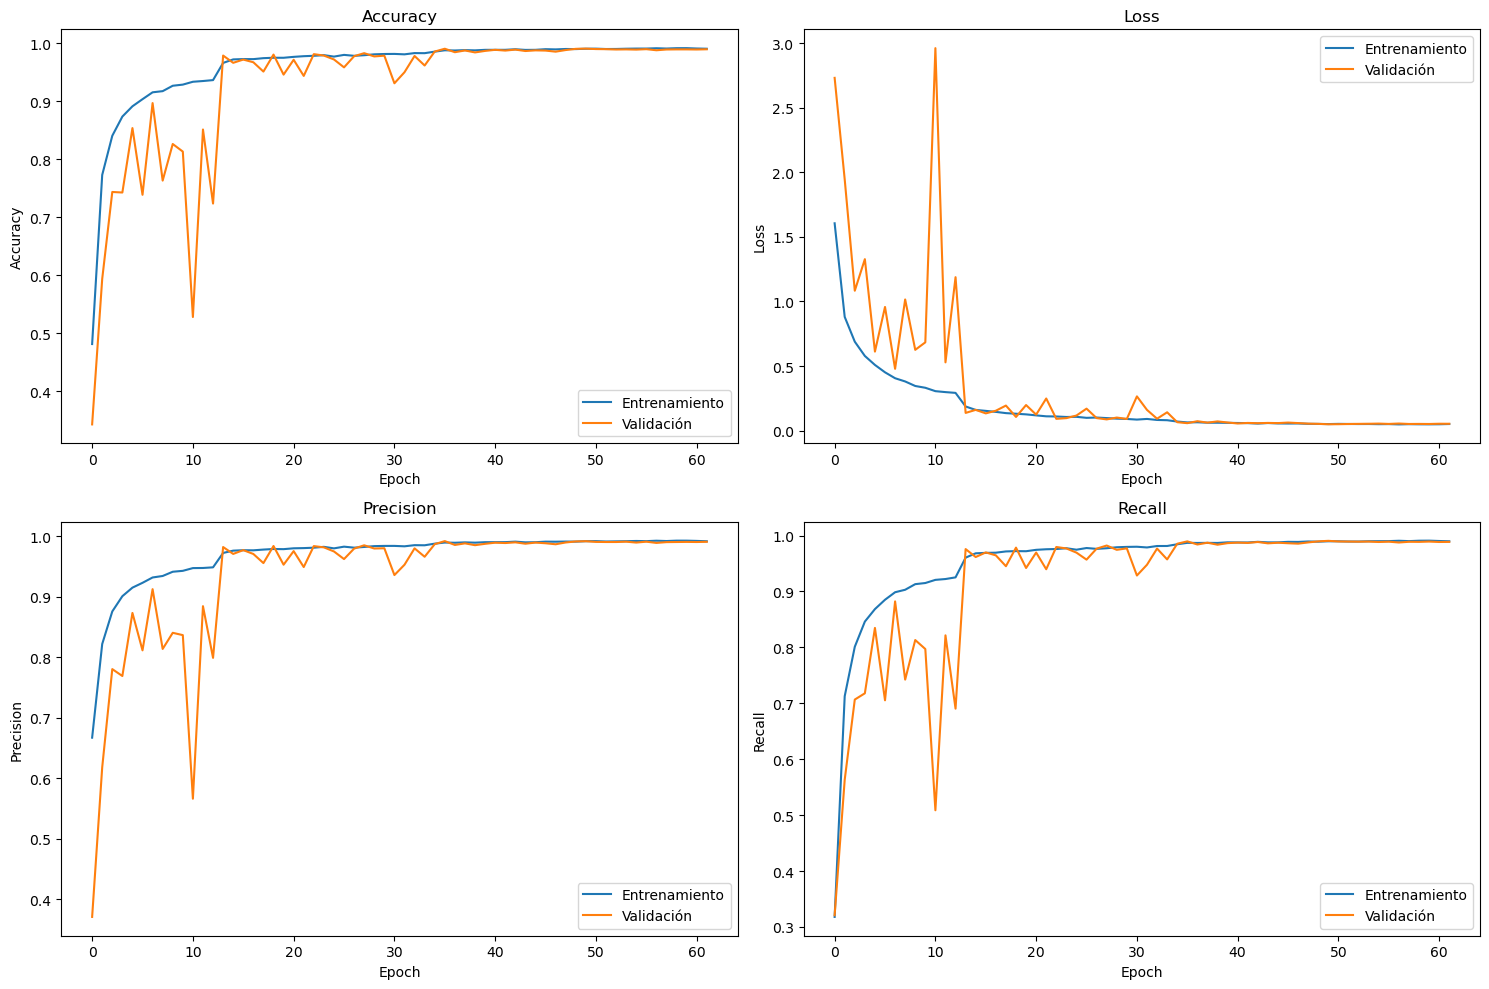

In [25]:
# Realizar un plot de las metricas para compararlas entre el conjunto de entrenamiento y el conjunto de validación
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0, 0].plot(history.history['val_accuracy'], label='Validación')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

axes[0, 1].plot(history.history['loss'], label='Entrenamiento')
axes[0, 1].plot(history.history['val_loss'], label='Validación')
axes[0, 1].set_title('Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

axes[1, 0].plot(history.history['precision'], label='Entrenamiento')
axes[1, 0].plot(history.history['val_precision'], label='Validación')
axes[1, 0].set_title('Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

axes[1, 1].plot(history.history['recall'], label='Entrenamiento')
axes[1, 1].plot(history.history['val_recall'], label='Validación')
axes[1, 1].set_title('Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


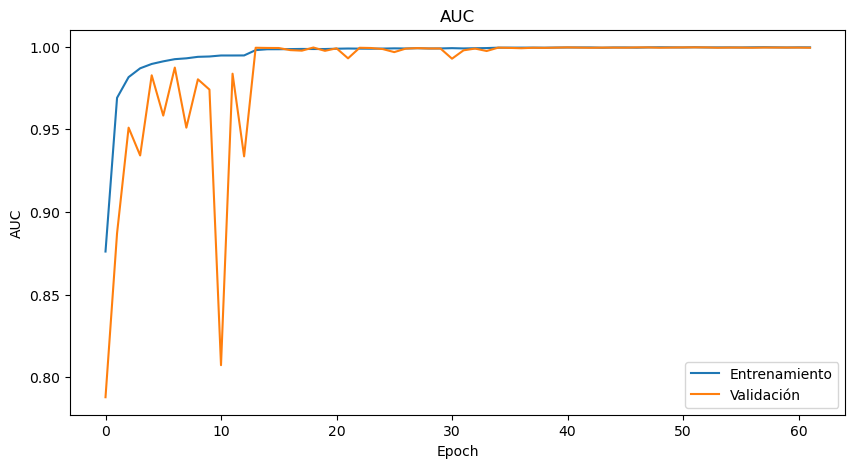

In [26]:
# Visualizar el AUC
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['auc'], label='Entrenamiento')
ax.plot(history.history['val_auc'], label='Validación')
ax.set_title('AUC')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.legend()
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

# Obtener las predicciones para el conjunto de prueba
y_pred_probs = model_1.predict(test_ds)

42/42 [==============================] - 130s 3s/step


In [99]:
# Obtener las etiquetas predichas del conjunto de prueba
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Obtener las etiquetas reales del conjunto de prueba
y_true = test_ds.labels

In [101]:
# Obtener la información de las clases y sus índices del generador de datos
class_indices_test = test_ds.class_indices

# Obtener los nombres de las clases a partir de los índices
class_names_test = list(class_indices_test.keys())

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_pred_labels)

# Crear un DataFrame de la matriz de confusión
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_names_test, columns=class_names_test)

# Calcular la accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# Calcular la precisión
precision = precision_score(y_true, y_pred_labels, average='weighted')

# Calcular el recall
recall = recall_score(y_true, y_pred_labels, average='weighted')

# Calcular el AUC
auc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')

print(f'AUC: {auc}')
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

AUC: 0.9999285254918446
Accuracy: 0.9891871737509321
Precision: 0.9892452214571914
Recall: 0.9891871737509321


In [119]:
class_indices_test

{'Basofilos': 0,
 'Eosinofilos': 1,
 'Eritroblastos': 2,
 'Linfoblastos': 3,
 'Linfocitos': 4,
 'Mieloblastos': 5,
 'Monocitos': 6,
 'Neutrofilos': 7,
 'Plaquetas': 8}

In [102]:
# Obtener el reporte de clasificación
print(classification_report(y_true, y_pred_labels, target_names=class_names))


               precision    recall  f1-score   support

    Basofilos       0.98      1.00      0.99       298
  Eosinofilos       0.99      1.00      1.00       298
Eritroblastos       0.99      1.00      0.99       298
 Linfoblastos       0.99      0.98      0.98       298
   Linfocitos       1.00      0.97      0.98       298
 Mieloblastos       0.98      0.99      0.99       298
    Monocitos       0.98      0.97      0.98       298
  Neutrofilos       1.00      0.99      0.99       298
    Plaquetas       1.00      1.00      1.00       298

     accuracy                           0.99      2682
    macro avg       0.99      0.99      0.99      2682
 weighted avg       0.99      0.99      0.99      2682



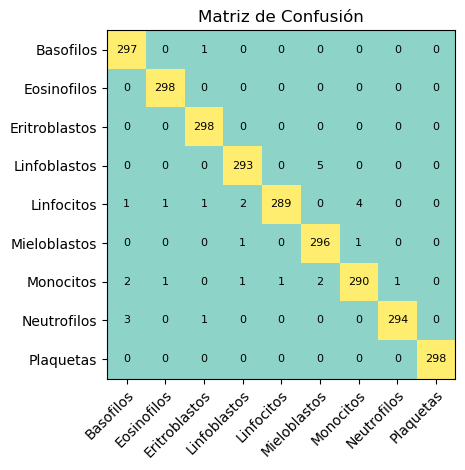

In [103]:
class_labels = conf_matrix_df.index.to_numpy()
conf_matrix = conf_matrix_df.to_numpy()

fig, ax = plt.subplots()

im = ax.imshow(conf_matrix, cmap='Set3')

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop sobre las dimensiones de los datos y crea anotaciones de texto
for i in range(len(class_labels)):
    for j in range(len(class_labels)):
        text = ax.text(j, i, conf_matrix[i, j],
                       ha="center", va="center", color="black", fontsize=8)

# Establece el título y ajusta el diseño
ax.set_title("Matriz de Confusión")
fig.tight_layout()
plt.show()


In [113]:
misclassified_indexes = np.where(y_pred_labels != y_true)[0]

In [116]:
print(len(misclassified_indexes))

29


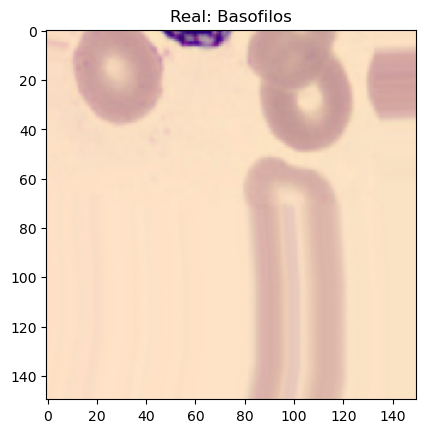

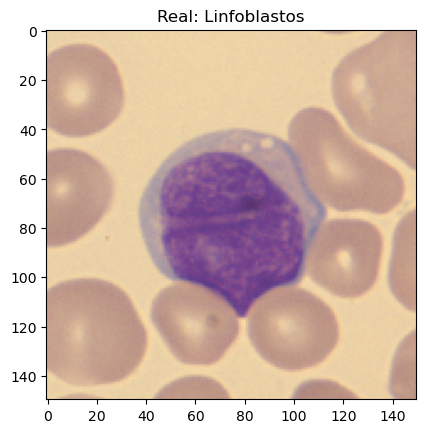

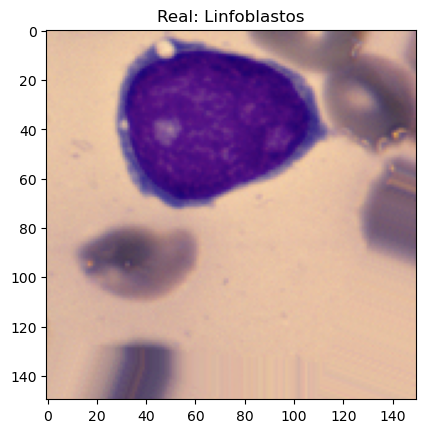

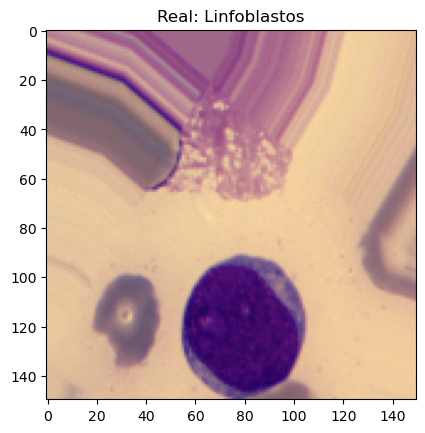

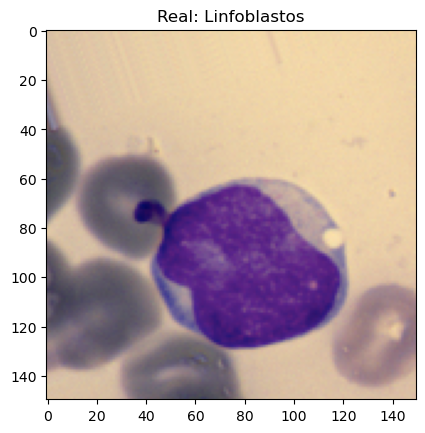

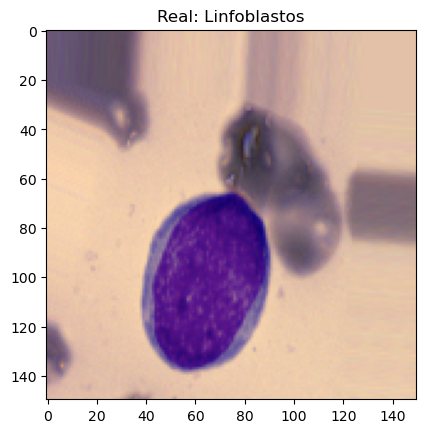

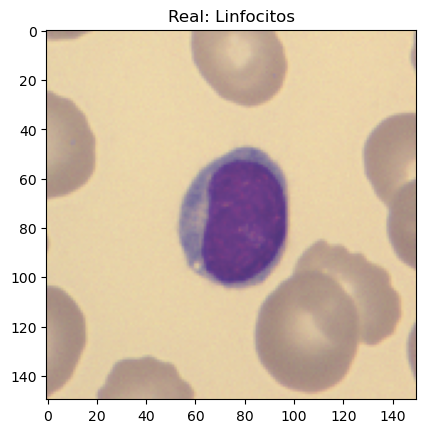

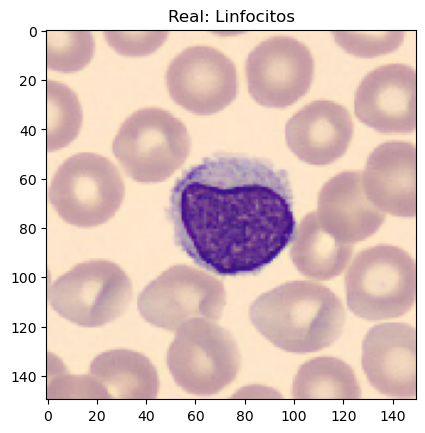

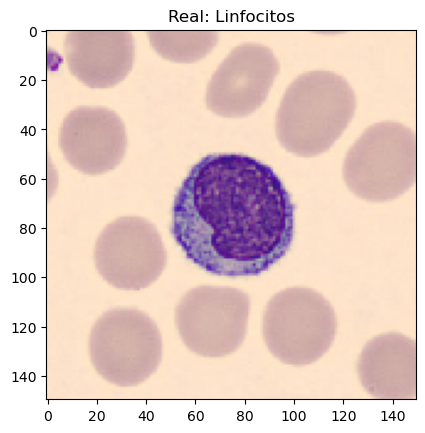

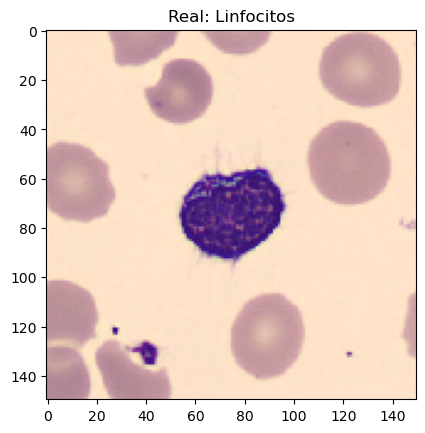

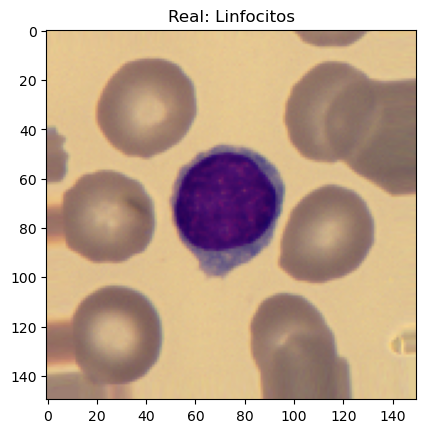

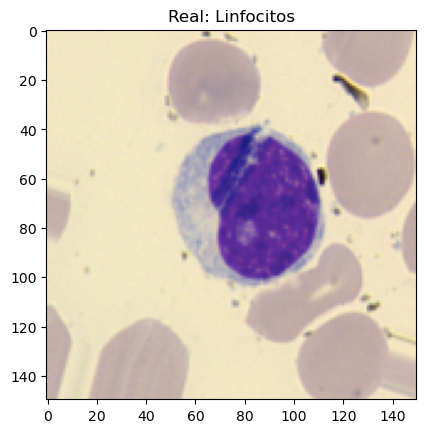

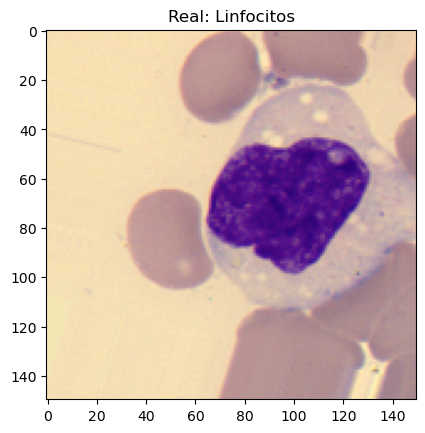

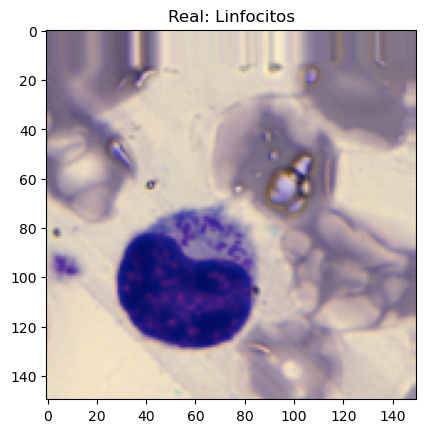

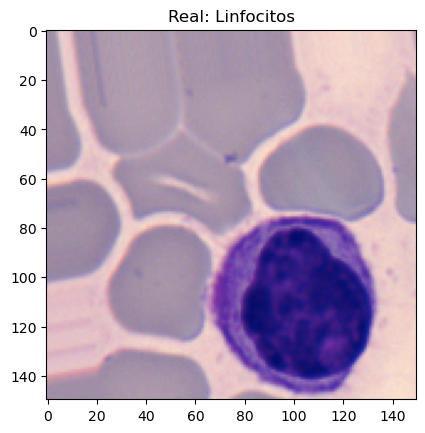

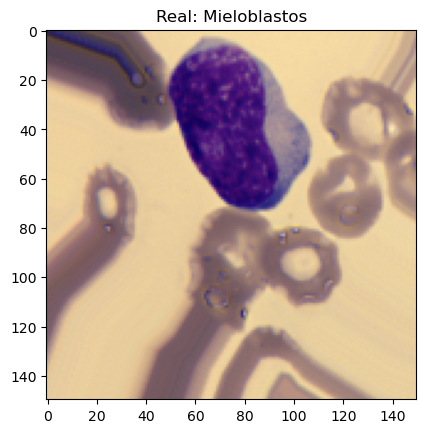

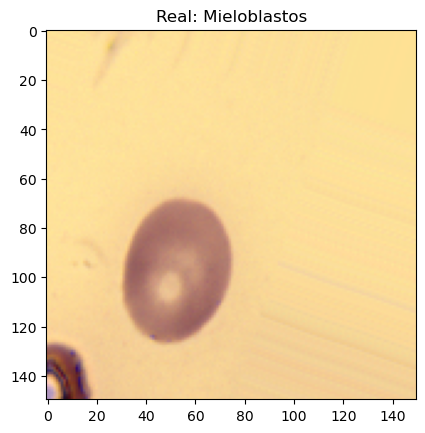

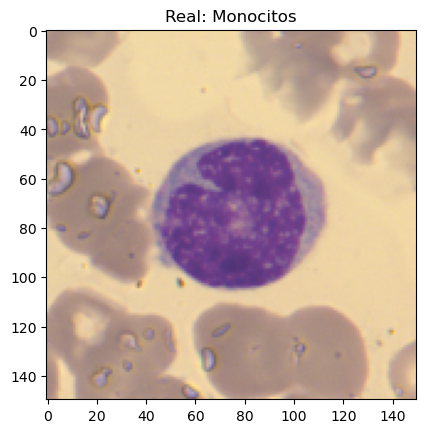

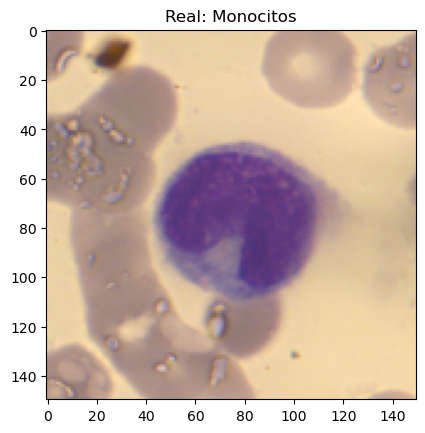

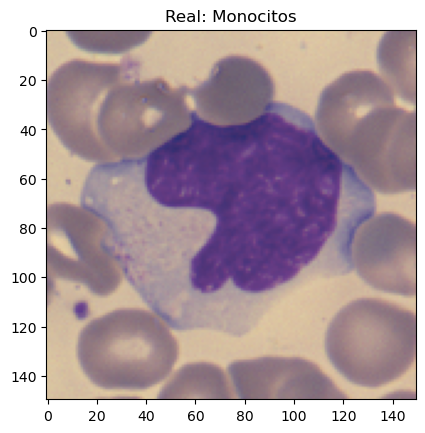

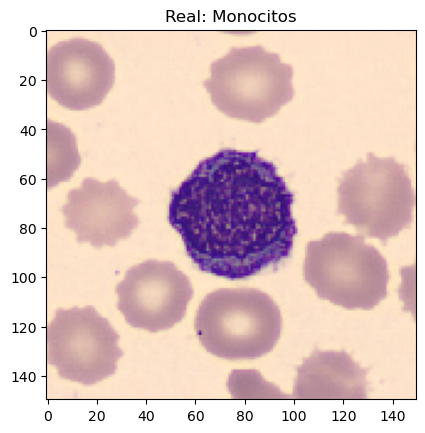

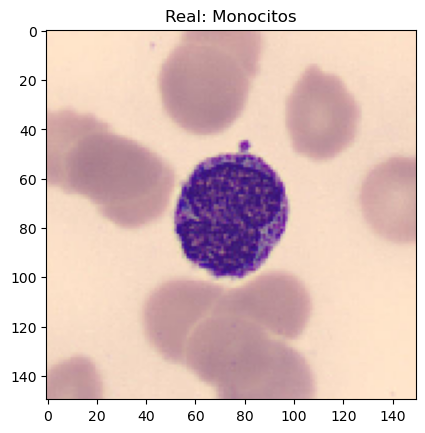

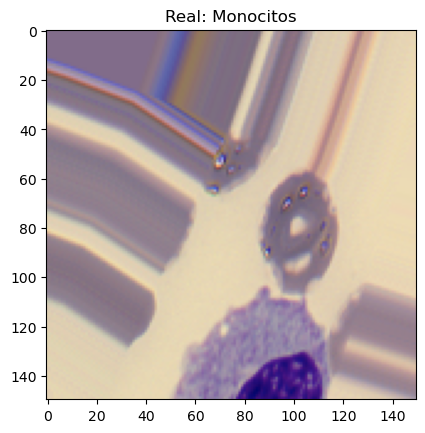

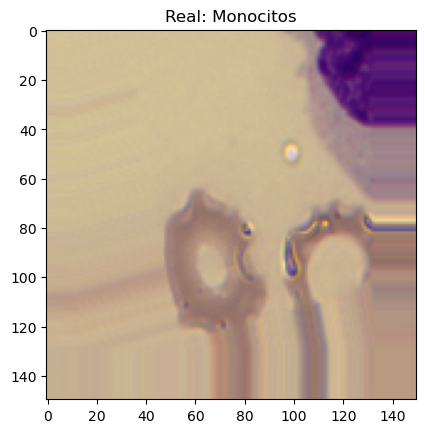

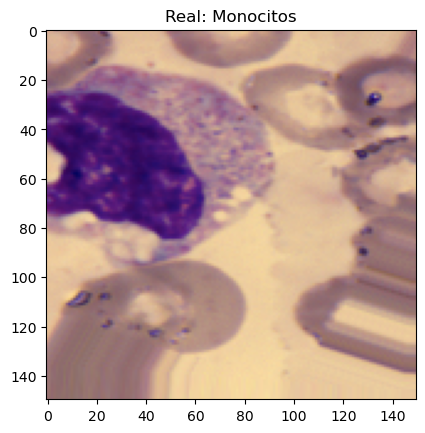

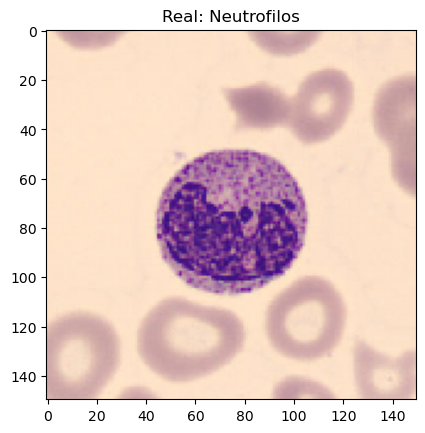

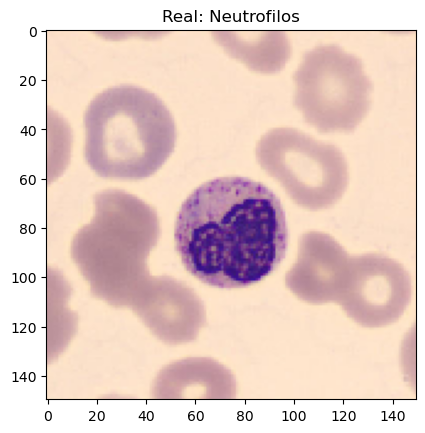

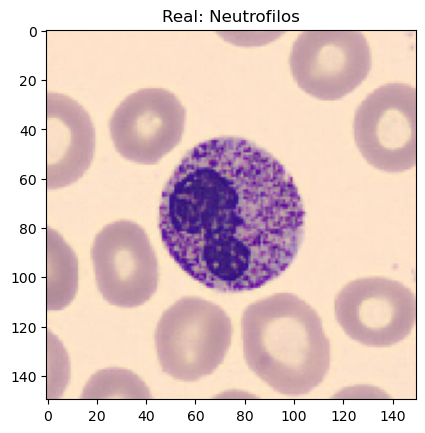

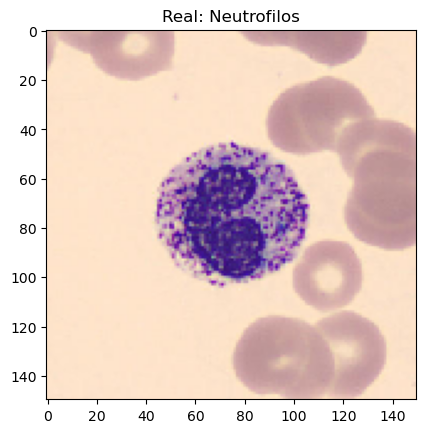

In [118]:
import matplotlib.pyplot as plt

# Obtener todas las imágenes y etiquetas reales del conjunto de datos de prueba
all_images = []
all_true_labels = []

for i in range(len(test_ds)):
    images, true_labels = test_ds[i]
    all_images.extend(images)
    all_true_labels.extend(true_labels)

# Iterar sobre los índices de las muestras mal clasificadas
for index in misclassified_indexes:
    # Obtener la imagen y su etiqueta real del conjunto de datos de prueba
    image = all_images[index]
    true_label = all_true_labels[index]
    
    # Convertir la imagen a un formato visualizable (por ejemplo, para matplotlib)
    visualizable_image = image  # No es necesario [0] si batch_size=1
    
    # Mostrar la imagen junto con la etiqueta real
    plt.imshow(visualizable_image)
    plt.title(f'Real: {class_names_test[np.argmax(true_label)]}')
    plt.show()

